In [ ]:

from google.colab import drive
drive.mount('/content/drive')

!pip install -q vit-pytorch torchmetrics matplotlib seaborn --no-cache-dir
!pip install -U torch torchvision --no-cache-dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 169.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 162.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 167.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 323.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 217.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 160.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 170.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 186.7 M

In [ ]:
# Import libraries
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models
from PIL import Image
from vit_pytorch import ViT
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split  # Added for stratified split
from tqdm.auto import tqdm

# Enable Tensor Cores and mixed precision for T4 GPU
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# Device configuration (will use T4 GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Data path in Google Drive
data_dir = "/content/drive/MyDrive/Colab Notebooks/Augmented"  # Update with your path
classes = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# Verify dataset structure and count samples per class
class_counts = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if not os.path.exists(cls_path):
        raise FileNotFoundError(f"Directory {cls_path} not found")
    count = len(os.listdir(cls_path))
    class_counts[cls] = count
    print(f"{cls}: {count} images")

# WHO Grading System Mapping
grade_mapping = {
    'glioma': 3,      # Grade IV (Glioblastoma)
    'meningioma': 0,  # Grade I
    'pituitary': 0,   # Grade I
    'no_tumor': -1    # Special case (no tumor)
}

grade_descriptions = [
    "Grade I (Least aggressive, benign)",
    "Grade II (Moderately aggressive)",
    "Grade III (Aggressive)",
    "Grade IV (Most aggressive, malignant)"
]

# Optimized Dataset Class with caching for T4 GPU
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_indices = {cls: [] for cls in classes}  # Track indices per class

        for class_idx, class_name in enumerate(classes):
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                idx = len(self.samples)  # Current index
                self.samples.append({
                    'path': img_path,
                    'type': class_idx,
                    'grade': grade_mapping[class_name]
                })
                self.class_indices[class_name].append(idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')
            if self.transform:
                image = self.transform(image)

            return {
                'image': image,
                'type': sample['type'],
                'grade': sample['grade']
            }
        except Exception as e:
            print(f"Error loading {sample['path']}: {e}")
            return self[np.random.randint(0, len(self))]

    def get_targets(self):
        """Get all targets for stratified splitting"""
        return [sample['type'] for sample in self.samples]

# Optimized transformations for T4 GPU - keep original size for now
transform = transforms.Compose([
    transforms.Resize((299, 299)), # Keep 299x299 for consistency
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = BrainTumorDataset(data_dir, transform=transform)

# Stratified split (80% train, 20% test) - maintaining class distribution
targets = full_dataset.get_targets()
train_indices, test_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

# Create subset datasets
train_dataset = Subset(full_dataset, train_indices)
test_dataset = Subset(full_dataset, test_indices)

# Verify the split maintains class distribution
def print_class_distribution(dataset, name):
    counts = {cls: 0 for cls in classes}
    for idx in dataset.indices if hasattr(dataset, 'indices') else range(len(dataset)):
        sample = full_dataset.samples[idx]
        counts[classes[sample['type']]] += 1
    print(f"\n{name} class distribution:")
    for cls in classes:
        print(f"{cls}: {counts[cls]} samples ({counts[cls]/len(dataset):.1%})")

print_class_distribution(train_dataset, "Training set")
print_class_distribution(test_dataset, "Test set")

# Optimized DataLoader settings for T4 GPU
num_workers = 2 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,  # Optimal batch size for T4 memory
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"\nDataset split:")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")


Using device: cuda (Tesla T4)
glioma: 2427 images
meningioma: 2438 images
pituitary: 2412 images
no_tumor: 1907 images

Training set class distribution:
glioma: 1941 samples (26.4%)
meningioma: 1950 samples (26.5%)
pituitary: 1930 samples (26.3%)
no_tumor: 1526 samples (20.8%)

Test set class distribution:
glioma: 486 samples (26.5%)
meningioma: 488 samples (26.6%)
pituitary: 482 samples (26.2%)
no_tumor: 381 samples (20.7%)

Dataset split:
Training samples: 7347
Testing samples: 1837


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 133MB/s]



Model architecture:
HybridTumorModel(
  (cnn): Inception3(
    (Conv2d_1a_3x3): BasicConv2d(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2a_3x3): BasicConv2d(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2b_3x3): BasicConv2d(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (Conv2d_3b_1x1): BasicConv2d(
      (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  

<ipython-input-4-4cb512c3f716>:98: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


...

Epoch 50:   0%|          | 0/230 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/58 [00:00<?, ?it/s]


Epoch 50/50 Summary:
Train Loss: 0.0003 | Type Acc: 99.99% | Grade Acc: 44776.92%
Val Loss: 0.0357 | Type Acc: 99.40% | Grade Acc: 18150.00%

Training completed!


Evaluating:   0%|          | 0/58 [00:00<?, ?it/s]


Final Test Performance:
Type Accuracy: 99.46%
Grade Accuracy: 18150.00% (on tumor cases only)

Type Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      1.00      0.99       486
  meningioma       0.99      0.99      0.99       488
   pituitary       1.00      1.00      1.00       482
    no_tumor       1.00      0.99      1.00       381

    accuracy                           0.99      1837
   macro avg       0.99      0.99      0.99      1837
weighted avg       0.99      0.99      0.99      1837


Grade Classification Report (tumor cases only):
                                       precision    recall  f1-score   support

   Grade I (Least aggressive, benign)       1.00      1.00      1.00       970
Grade IV (Most aggressive, malignant)       1.00      1.00      1.00       486

                             accuracy                           1.00      1456
                            macro avg       1.00      1.00      1.00      

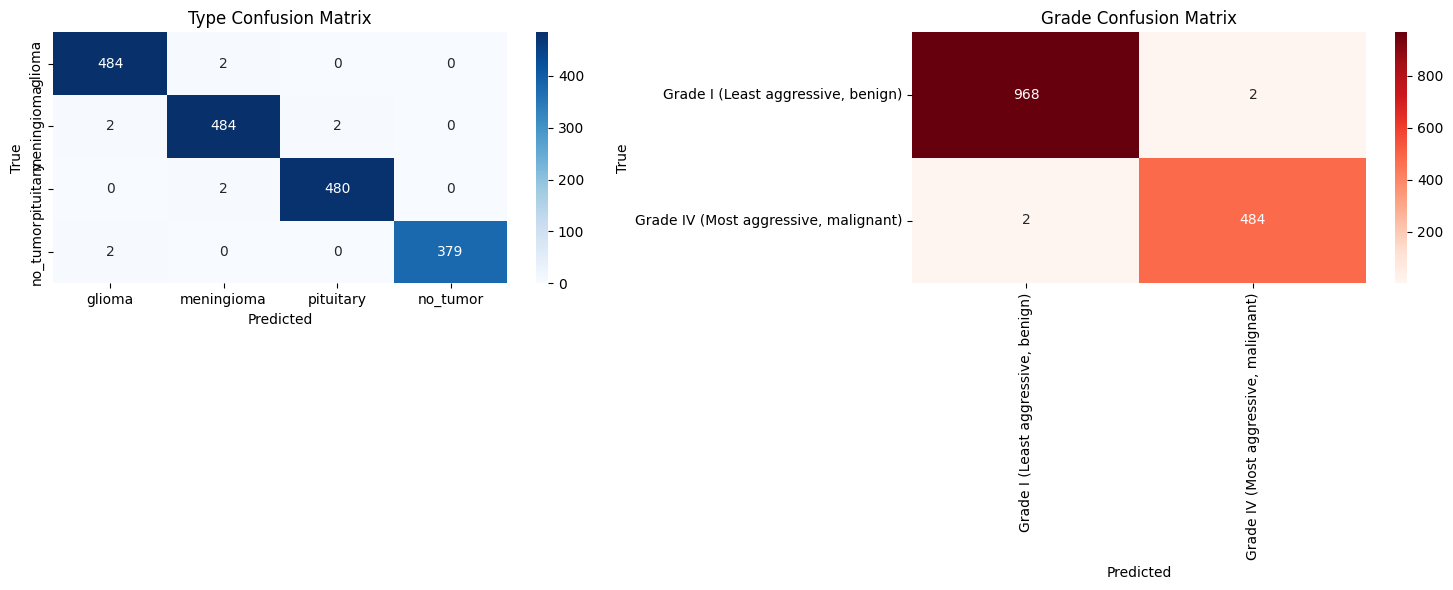

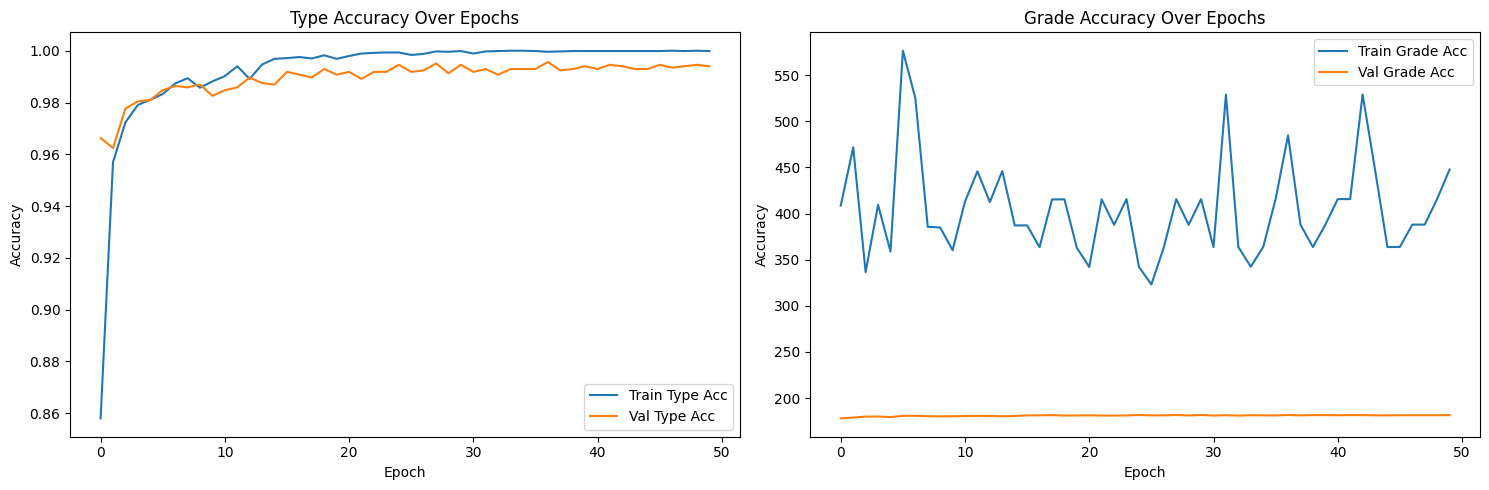

In [ ]:
# Hybrid InceptionV3-ViT Model optimized for T4 GPU
class HybridTumorModel(nn.Module):
    def __init__(self, num_types=4, num_grades=4):
        super().__init__()

        # CNN Backbone (InceptionV3)
        self.cnn = models.inception_v3(pretrained=True, aux_logits=True)
        # Extract features before the classifier and auxiliary classifiers
        self.cnn_features = nn.Sequential(
            self.cnn.Conv2d_1a_3x3,
            self.cnn.Conv2d_2a_3x3,
            self.cnn.Conv2d_2b_3x3,
            self.cnn.maxpool1,
            self.cnn.Conv2d_3b_1x1,
            self.cnn.Conv2d_4a_3x3,
            self.cnn.maxpool2,
            self.cnn.Mixed_5b,
            self.cnn.Mixed_5c,
            self.cnn.Mixed_5d,
            self.cnn.Mixed_6a,
            self.cnn.Mixed_6b,
            self.cnn.Mixed_6c,
            self.cnn.Mixed_6d,
            self.cnn.Mixed_6e,
            self.cnn.Mixed_7a,
            self.cnn.Mixed_7b,
            self.cnn.Mixed_7c,
            # The output of Mixed_7c is before the AdaptiveAvgPool2d and final classifier
        )


        # Vision Transformer (Lightweight for T4)
        self.vit = ViT(
            image_size=224,  # ViT input size (divisible by patch size)
            patch_size=32,
            num_classes=768,
            dim=768,
            depth=4,  # Reduced depth for T4 memory
            heads=8,  # Reduced heads
            mlp_dim=1536,
            dropout=0.1,
            emb_dropout=0.1
        )

        # Feature fusion with proper dimensions
        # InceptionV3 output features after Mixed_7c are 2048 channels with spatial dimensions
        # We need to apply pooling to get a fixed size feature vector
        self.cnn_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.cnn_proj = nn.Linear(2048, 384)
        self.vit_proj = nn.Linear(768, 384)

        # Classifiers
        self.type_classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_types)
        )

        self.grade_classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades)
        )
        # Resizing transforms for the forward pass
        self.resize_cnn = transforms.Resize((299, 299))
        self.resize_vit = transforms.Resize((224, 224))


    def forward(self, x):
        # Resize input for CNN and ViT backbones
        x_cnn = self.resize_cnn(x)
        x_vit = self.resize_vit(x)

        # CNN features
        cnn_feats = self.cnn_features(x_cnn)
        # Apply pooling after feature extraction
        cnn_feats = self.cnn_pool(cnn_feats)
        cnn_feats = cnn_feats.view(cnn_feats.size(0), -1)
        cnn_feats = self.cnn_proj(cnn_feats)

        # ViT features
        vit_feats = self.vit(x_vit)
        vit_feats = self.vit_proj(vit_feats)

        # Feature fusion (element-wise addition)
        fused = cnn_feats + vit_feats

        # Multi-task output
        type_logits = self.type_classifier(fused)
        grade_logits = self.grade_classifier(fused)

        return type_logits, grade_logits

# Initialize model with mixed precision
model = HybridTumorModel().to(device)
scaler = torch.cuda.amp.GradScaler()

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Loss functions
type_criterion = nn.CrossEntropyLoss()
grade_criterion = nn.CrossEntropyLoss(ignore_index=-1)

# Optimizer (AdamW with weight decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Save directory
save_dir = "/content/drive/MyDrive/BrainTumorModelsforInceptionV3-ViT Model"
os.makedirs(save_dir, exist_ok=True)

# Training loop with mixed precision for T4 GPU
def train_epoch(epoch):
    model.train()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        images = batch['image'].to(device, non_blocking=True)
        types = batch['type'].to(device, non_blocking=True)
        grades = batch['grade'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision training
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_pred, grade_pred = model(images)
            loss_type = type_criterion(type_pred, types)
            loss_grade = grade_criterion(grade_pred, grades)
            loss = 0.6 * loss_type + 0.4 * loss_grade

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        running_loss += loss.item() * images.size(0)
        _, type_predicted = torch.max(type_pred, 1)
        type_correct += (type_predicted == types).sum().item()

        grade_mask = grades != -1
        if grade_mask.any():
            _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
            grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

        total += images.size(0)
        pbar.set_postfix({
            'Loss': running_loss/total,
            'Type Acc': type_correct/total,
            'LR': optimizer.param_groups[0]['lr']
        })

    epoch_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return epoch_loss, type_acc, grade_acc

def evaluate():
    model.eval()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    all_type_preds = []
    all_type_labels = []
    all_grade_preds = []
    all_grade_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch['image'].to(device, non_blocking=True)
            types = batch['type'].to(device, non_blocking=True)
            grades = batch['grade'].to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                type_pred, grade_pred = model(images)
                loss_type = type_criterion(type_pred, types)
                loss_grade = grade_criterion(grade_pred, grades)
                loss = 0.6 * loss_type + 0.4 * loss_grade

            running_loss += loss.item() * images.size(0)
            _, type_predicted = torch.max(type_pred, 1)
            type_correct += (type_predicted == types).sum().item()

            grade_mask = grades != -1
            if grade_mask.any():
                _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
                grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

            total += images.size(0)

            all_type_preds.extend(type_predicted.cpu().numpy())
            all_type_labels.extend(types.cpu().numpy())
            if grade_mask.any():
                all_grade_preds.extend(grade_predicted.cpu().numpy())
                all_grade_labels.extend(grades[grade_mask].cpu().numpy())

    avg_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return avg_loss, type_acc, grade_acc, all_type_preds, all_type_labels, all_grade_preds, all_grade_labels

# Training parameters
num_epochs = 50  # Reduced epochs for Colab demo
best_acc = 0.0

train_losses = []
val_losses = []
train_type_accs = []
val_type_accs = []
train_grade_accs = []
val_grade_accs = []

# Training loop
print("\nStarting training...")
for epoch in range(num_epochs):
    train_loss, train_type_acc, train_grade_acc = train_epoch(epoch)
    val_loss, val_type_acc, val_grade_acc, _, _, _, _ = evaluate()
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_type_accs.append(train_type_acc)
    val_type_accs.append(val_type_acc)
    train_grade_accs.append(train_grade_acc)
    val_grade_accs.append(val_grade_acc)

    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Type Acc: {train_type_acc:.2%} | Grade Acc: {train_grade_acc:.2%}")
    print(f"Val Loss: {val_loss:.4f} | Type Acc: {val_type_acc:.2%} | Grade Acc: {val_grade_acc:.2%}")

    # Save best model
    if val_type_acc > best_acc:
        best_acc = val_type_acc
        model_path = os.path.join(save_dir, "best_model_inception_t4.pth")
        torch.save(model.state_dict(), model_path)
        print(f"Saved new best model to {model_path}")

print("\nTraining completed!")

# Load best model
model.load_state_dict(torch.load(os.path.join(save_dir, "best_model_inception_t4.pth")))
model.eval()

# Final evaluation
test_loss, test_type_acc, test_grade_acc, type_preds, type_labels, grade_preds, grade_labels = evaluate()
print(f"\nFinal Test Performance:")
print(f"Type Accuracy: {test_type_acc:.2%}")
print(f"Grade Accuracy: {test_grade_acc:.2%} (on tumor cases only)")

# Classification reports
print("\nType Classification Report:")
print(classification_report(type_labels, type_preds, target_names=classes))

print("\nGrade Classification Report (tumor cases only):")
if len(grade_labels) > 0:
    unique_grades = np.unique(grade_labels)
    print(classification_report(
        grade_labels,
        grade_preds,
        labels=unique_grades,
        target_names=[grade_descriptions[i] for i in unique_grades]
    ))

# Confusion matrices
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
cm_type = confusion_matrix(type_labels, type_preds)
sns.heatmap(cm_type, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Type Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

if len(grade_labels) > 0:
    plt.subplot(1, 2, 2)
    cm_grade = confusion_matrix(grade_labels, grade_preds, labels=unique_grades)
    sns.heatmap(cm_grade, annot=True, fmt='d', cmap='Reds',
                xticklabels=[grade_descriptions[i] for i in unique_grades],
                yticklabels=[grade_descriptions[i] for i in unique_grades])
    plt.title('Grade Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_type_accs, label='Train Type Acc')
plt.plot(val_type_accs, label='Val Type Acc')
plt.title('Type Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_grade_accs, label='Train Grade Acc')
plt.plot(val_grade_accs, label='Val Grade Acc')
plt.title('Grade Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Prediction function for custom images
def predict_tumor(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
    except:
        print(f"Error loading image: {image_path}")
        return None

    with torch.no_grad():
        # Apply transformations used for training data
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_logits, grade_logits = model(img_tensor)

    type_probs = torch.softmax(type_logits, dim=1)[0]
    grade_probs = torch.softmax(grade_logits, dim=1)[0]

    type_idx = torch.argmax(type_probs).item()
    tumor_type = classes[type_idx]
    type_conf = float(type_probs[type_idx])

    result = {
        'tumor_detected': tumor_type != 'no_tumor',
        'type': tumor_type,
        'type_confidence': type_conf,
        'grade': None,
        'grade_confidence': None,
        'characteristics': []
    }

    if result['tumor_detected']:
        grade_idx = torch.argmax(grade_probs).item()
        result.update({
            'grade': grade_descriptions[grade_idx],
            'grade_confidence': float(grade_probs[grade_idx]),
            'characteristics': [
                "Diffuse growth pattern" if tumor_type == 'glioma' else "Well-circumscribed",
                "High recurrence risk" if grade_idx >= 2 else "Low recurrence risk",
                "Aggressive" if grade_idx >= 2 else "Less aggressive"
            ]
        })

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Input Image\n{os.path.basename(image_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    info_text = f"Type: {tumor_type} ({type_conf:.1%})"
    if result['tumor_detected']:
        info_text += f"\nGrade: {result['grade']}\nCharacteristics:\n- " + "\n- ".join(result['characteristics'])
    plt.text(0.1, 0.5, info_text, fontsize=12, va='center')
    plt.axis('off')
    plt.show()

    return result

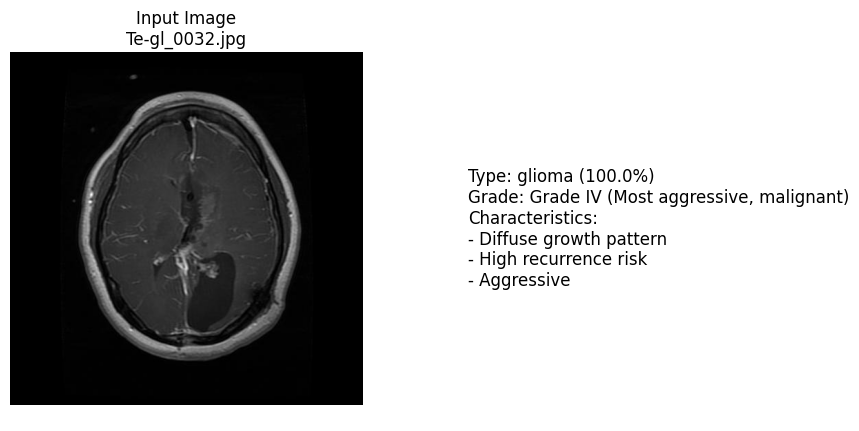


Prediction Result:
      tumor_detected: True
                type: glioma
     type_confidence: 1.0
               grade: Grade IV (Most aggressive, malignant)
    grade_confidence: 1.0
     characteristics: ['Diffuse growth pattern', 'High recurrence risk', 'Aggressive']


In [ ]:

# Example prediction
sample_image ="/content/drive/MyDrive/Colab Notebooks/image/Te-gl_0032.jpg"  # Replace with your image
prediction = predict_tumor(sample_image)

if prediction:
    print("\nPrediction Result:")
    for k, v in prediction.items():
        print(f"{k:>20}: {v}")